<div style="text-align: center;">
<div align="center">

**DESERCIÓN DE CLIENTES EN TELECOMUNICACIONES**

<br>

</div>

<div align="center">

**Juan Sebastian Alvarez Ortegon**  
**Maria Natalia Medina Rojas**  
**Sol Daniela Rodriguez Castellanos**  
**Valery Mariana Sanchez Albarracin**

<br>

Universidad EAN  
Facultad de Ingeniería  
Programa de Ingeniería de Sistemas

<br>

DataXperience

Camila Silva

<br>

13 de septiembre de 2026

</div>

#**Introduccion**
La retención de clientes es uno de los mayores retos para las empresas de telecomunicaciones, un sector caracterizado por una alta competencia y por la facilidad con la que los usuarios pueden cambiar de proveedor. Este fenómeno, conocido como churn o deserción de clientes, tiene un impacto directo en los ingresos de las compañías, ya que el costo de retener a un cliente existente suele ser considerablemente menor que el de adquirir uno nuevo. Por esta razón, anticipar qué clientes tienen mayor probabilidad de abandonar el servicio se ha convertido en una prioridad estratégica, y la ciencia de datos ofrece herramientas concretas para abordar este problema de forma objetiva y basada en evidencia.

El presente informe documenta el desarrollo completo de un proyecto de ciencia de datos aplicado al análisis de la deserción de clientes en una empresa de telecomunicaciones, utilizando el conjunto de datos Telco Customer Churn. A lo largo del documento se detalla cada etapa del proceso: desde la comprensión y limpieza de los datos, pasando por el análisis exploratorio y estadístico de las variables disponibles, hasta la construcción, evaluación e interpretación de modelos predictivos de clasificación. El objetivo es no solo obtener un modelo capaz de predecir el abandono, sino también comprender y comunicar con claridad qué factores influyen en esta decisión, de modo que los hallazgos puedan traducirse en recomendaciones accionables para el negocio.

#**Planteamiento Problema**
Las empresas de telecomunicaciones pueden perder clientes que deciden cancelar sus servicios. Esto representa un problema porque es importante conocer qué factores están relacionados con el abandono para poder tomar decisiones que ayuden a conservar a los clientes.

#**Objetivo General**
Analizar la relación entre las características de los clientes y el abandono de los servicios de telecomunicaciones, mediante la limpieza, procesamiento y análisis exploratorio de los datos utilizando Python.

#**Pregunta Principal**
¿Qué relación existe entre el tipo de contrato, el servicio de internet, el método de pago y la antigüedad de los clientes con su abandono (Churn) en una empresa de telecomunicaciones?

#**Preguntas De Apoyo**
1. ¿Qué relación existe entre las variables de comportamiento de los clientes y su abandono?
2. ¿Cómo varía el cargo mensual de los clientes según el tipo de servicio de internet contratado?
3. ¿Cuáles características presentan mayor capacidad para diferenciar a los clientes que abandonan de aquellos que permanecen activos?
4. ¿Cómo influye la relación de pareja en la deserción de los servicios de telecomunicación?


#**Estructura Y Origen De La Base De Datos**
##1. Origen Y Fuente De Los Datos
Fuente: Repositorio público de Kaggle (Telco Customer Churn Dataset).

Proveedor Original: Base de datos corporativa de IBM Cognos Analytics.

Periodo / Año del Dataset: Datos rpublicados en 2023.

##2. Dimensiones Del DataSet

Total de Filas (Registros): 7,043 clientes analizados.

Total de Columnas (Variables): 21 variables registradas.

## 3. Variables del Dataset

El dataset está compuesto por 21 variables, agrupadas en tres categorías:

**Información demográfica (5):**

| Variable | Descripción |
|---|---|
| `customerID` | ID del cliente |
| `gender` | Género (Femenino / Masculino) |
| `SeniorCitizen` | Adulto mayor (1: Sí, 0: No) |
| `Partner` | Si tiene pareja (Sí / No) |
| `Dependents` | Si tiene personas a cargo / dependientes (Sí / No) |

**Servicios contratados (9):**

| Variable | Descripción |
|---|---|
| `tenure` | Antigüedad del cliente en meses |
| `PhoneService` | Servicio de telefonía fija (Sí / No) |
| `MultipleLines` | Múltiples líneas telefónicas |
| `InternetService` | Tipo de internet (DSL, Fibra Óptica, No) |
| `OnlineSecurity` | Servicio de seguridad en línea |
| `OnlineBackup` | Servicio de copia de seguridad en la nube |
| `DeviceProtection` | Protección de dispositivos / equipos |
| `TechSupport` | Soporte técnico prioritario |
| `StreamingTV` | Servicio de televisión por streaming |
| `StreamingMovies` | Servicio de películas por streaming |

**Facturación, contrato y estado (7):**

| Variable | Descripción |
|---|---|
| `Contract` | Tipo de contrato (mes a mes, 1 año, 2 años) |
| `PaperlessBilling` | Facturación electrónica / sin papel |
| `PaymentMethod` | Método de pago (cheque electrónico, cheque por correo, transferencia bancaria, tarjeta de crédito) |
| `MonthlyCharges` | Cargo mensual a pagar en USD |
| `TotalCharges` | Cobro total acumulado pagado por el cliente en USD |
| `Churn` (variable objetivo) | Deserción del cliente (Yes: canceló el servicio / No: sigue activo) |




#Base De Datos

Jethwaaatmik. (2025). Telco customer churn dataset [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/jethwaaatmik/telco-customer-churn-dataset

#Limpieza
1. Antes de limpiar, se debe hacer un diagnostico completo de la base de datos para identificar los problemas de calidad presentes. El archivo se cargó desde Google Drive mediante pd.read_csv(), y como buena práctica se creó una copia de trabajo (df_limpio = df.copy()) para preservar el dataset original intacto durante todo el proceso.

In [ ]:
import pandas as pd
import numpy as np


ruta = "/content/telco_data.csv"
df = pd.read_csv(ruta)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("=" * 60)
print("1) DIMENSIONES")
print("=" * 60)
print(f"   {df.shape[0]} filas x {df.shape[1]} columnas")

print("\n" + "=" * 60)
print("2) TIPOS Y DATOS PRESENTES")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("3) FALTANTES POR COLUMNA")
print("=" * 60)
print(df.isna().sum())

print("\n" + "=" * 60)
print("4) FILAS COMPLETAMENTE DUPLICADAS")
print("=" * 60)
print(f"   {df.duplicated().sum()} filas repetidas")
print(f"   {df.duplicated(subset=['customerID']).sum()} customerID repetidos")

print("=" * 60)
print("5) ESTADISTICOS DE LAS COLUMNAS NUMERICAS")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("6) VALORES UNICOS DE LAS COLUMNAS DE TEXTO")
print("=" * 60)
columnas_texto = df.select_dtypes(include="object").columns.drop("customerID")
for col in columnas_texto:
    print(f"\n--- {col}: {df[col].nunique()} valores distintos ---")
    print(df[col].value_counts(dropna=False))

1) DIMENSIONES
   7043 filas x 21 columnas

2) TIPOS Y DATOS PRESENTES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          

El diagnóstico reveló cuatro hallazgos principales. Primero, la base contiene 7.043 clientes y 21 variables. Segundo, la columna TotalCharges estaba almacenada como texto (object) en lugar de tipo numérico, lo cual impedía realizar operaciones matemáticas sobre ella. Tercero, se identificaron 8.250 celdas vacías, concentradas principalmente en tenure (2.500 de 7.043 registros, más de un tercio de la base). Finalmente, no se encontraron filas ni identificadores de cliente (customerID) duplicados, y los boxplots de las variables numéricas confirmaron que no existían valores atípicos o imposibles (por ejemplo, cargos negativos o antigüedades fuera de rango).

2. Para realizar la limpieza se siguen 6 pasos esenciales:

1.Nombres de columnas

2.Duplicados

3.Texto y categorías equivalentes

4.Valores imposibles

5.Valores atípicos

6.Valores faltantes

In [ ]:
df_limpio = df.copy()   # a partir de aqui  todo se escribe sobre df_limpio osea la copia
#1.

print("Antes:", list(df_limpio.columns))

# Minuscula y sin espacios sobrantes.
# Los nombres originales vienen en CamelCase pegado
# Asi que basta con pasar todo a minuscula
df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.lower()
)

print("Despues:", list(df_limpio.columns))

Antes: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Despues: ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [ ]:
# 2.
antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates(subset=["customerid"])
print(f"Filas antes: {antes}  ->  despues: {len(df_limpio)}  (se eliminaron {antes - len(df_limpio)})")
# No se elimino nada cada customerid aparece una sola vez.

Filas antes: 7043  ->  despues: 7043  (se eliminaron 0)


In [ ]:
#3.
columnas_texto = df_limpio.select_dtypes(include="object").columns.drop("customerid")

cambios = 0
for col in columnas_texto:
    original = df_limpio[col].copy()
    df_limpio[col] = df_limpio[col].str.strip()
    cambios += (original != df_limpio[col]).sum()

print(f"Celdas de texto con espacios sobrantes que se corrigieron: {cambios}")
print("\nConfirmando que las categorias ya son consistentes, ej. 'contract':")
print(df_limpio["contract"].unique())

Celdas de texto con espacios sobrantes que se corrigieron: 4261

Confirmando que las categorias ya son consistentes, ej. 'contract':
['Month-to-month' 'One year' 'Two year']


In [ ]:
#4.
revisar_tc = pd.to_numeric(df_limpio["totalcharges"], errors="coerce")
filas_problema = df_limpio.loc[revisar_tc.isna(), ["customerid", "tenure", "monthlycharges", "totalcharges"]]

print(f"Filas donde 'totalcharges' NO es un numero valido: {len(filas_problema)}")
filas_problema

Filas donde 'totalcharges' NO es un numero valido: 11


,customerid,tenure,monthlycharges,totalcharges
488,4472-LVYGI,0.0,52.55,
753,3115-CZMZD,0.0,20.25,
936,5709-LVOEQ,0.0,80.85,
1082,4367-NUYAO,0.0,25.75,
1340,1371-DWPAZ,NaN,56.05,
3331,7644-OMVMY,0.0,19.85,
3826,3213-VVOLG,0.0,25.35,
4380,2520-SGTTA,0.0,20.00,
5218,2923-ARZLG,0.0,19.70,
6670,4075-WKNIU,NaN,NaN,


In [ ]:

df_limpio["totalcharges"] = pd.to_numeric(df_limpio["totalcharges"], errors="coerce")
print("Tipo de dato ahora:", df_limpio["totalcharges"].dtype)
print("Faltantes en totalcharges:", df_limpio["totalcharges"].isna().sum())

Tipo de dato ahora: float64
Faltantes en totalcharges: 11


In [ ]:

print("tenure fuera de [0, 72]:", ((df_limpio["tenure"] < 0) | (df_limpio["tenure"] > 72)).sum())
print("monthlycharges negativo   :", (df_limpio["monthlycharges"] < 0).sum())
print("totalcharges negativo     :", (df_limpio["totalcharges"] < 0).sum())
print("valores de seniorcitizen  :", sorted(df_limpio["seniorcitizen"].unique()))

tenure fuera de [0, 72]: 0
monthlycharges negativo   : 0
totalcharges negativo     : 0
valores de seniorcitizen  : [np.int64(0), np.int64(1)]


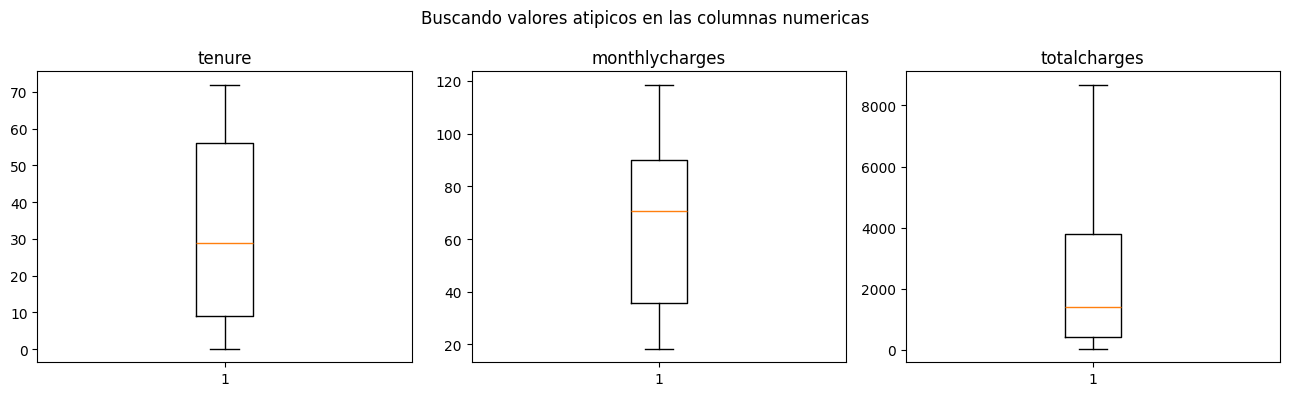

tenure           -> rango normal [   -61.5,    126.5]   atipicos: 0
monthlycharges   -> rango normal [   -45.5,    171.2]   atipicos: 0
totalcharges     -> rango normal [ -4688.5,   8884.7]   atipicos: 0


In [ ]:
#5
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(ejes, ["tenure", "monthlycharges", "totalcharges"]):
    ax.boxplot(df_limpio[col].dropna())
    ax.set_title(col)
plt.suptitle("Buscando valores atipicos en las columnas numericas")
plt.tight_layout()
plt.show()

for col in ["tenure", "monthlycharges", "totalcharges"]:
    q1, q3 = df_limpio[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_bajo, limite_alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = ((df_limpio[col] < limite_bajo) | (df_limpio[col] > limite_alto)).sum()
    print(f"{col:16s} -> rango normal [{limite_bajo:8.1f}, {limite_alto:8.1f}]   atipicos: {atipicos}")

In [ ]:
#6
print("Faltantes por columna (despues de los pasos 1 a 5):")
print(df_limpio.isna().sum().sort_values(ascending=False))
print()
total_celdas = df_limpio.shape[0] * df_limpio.shape[1]
total_vacias = df_limpio.isna().sum().sum()
print(f"Total: {total_vacias} celdas vacias de {total_celdas} ({total_vacias/total_celdas:.1%})")

Faltantes por columna (despues de los pasos 1 a 5):
tenure              2500
streamingtv         1500
monthlycharges      1500
internetservice     1000
partner             1000
gender               750
totalcharges          11
customerid             0
seniorcitizen          0
dependents             0
onlinesecurity         0
phoneservice           0
multiplelines          0
techsupport            0
deviceprotection       0
onlinebackup           0
streamingmovies        0
paperlessbilling       0
contract               0
paymentmethod          0
churn                  0
dtype: int64

Total: 8261 celdas vacias de 147903 (5.6%)


In [ ]:
# Verificacion rapida: ¿la tasa de churn es distinta entre filas con y sin dato faltante?
# Si NO es distinta, el faltante probablemente es aleatorio (no esconde un sesgo).
# Si SI es distinta, hay que ser mas cuidadosos: el faltante mismo es informacion.
for col in ["tenure", "monthlycharges", "gender", "partner", "internetservice", "streamingtv"]:
    falta = df_limpio[col].isna()
    tasa_falta = df_limpio.loc[falta, "churn"].eq("Yes").mean() * 100
    tasa_no_falta = df_limpio.loc[~falta, "churn"].eq("Yes").mean() * 100
    print(f"{col:18s} -> churn si falta: {tasa_falta:5.1f}%   churn si NO falta: {tasa_no_falta:5.1f}%")

tenure             -> churn si falta:  27.1%   churn si NO falta:  26.2%
monthlycharges     -> churn si falta:  26.5%   churn si NO falta:  26.5%
gender             -> churn si falta:  27.6%   churn si NO falta:  26.4%
partner            -> churn si falta:  26.5%   churn si NO falta:  26.5%
internetservice    -> churn si falta:  26.5%   churn si NO falta:  26.5%
streamingtv        -> churn si falta:  26.5%   churn si NO falta:  26.5%


Los resultados muestran que la tasa de churn es prácticamente idéntica entre clientes con y sin dato faltante en todas las variables analizadas (por ejemplo, tenure: 27.1% vs. 26.2%; monthlycharges: 27.6% vs. 26.4%). Esto indica que los valores faltantes no esconden un sesgo relacionado con el abandono, sino que corresponden a datos que simplemente no se registraron, sin un patrón de negocio detrás. Esta conclusión respalda la decisión de imputar los valores faltantes en lugar de eliminarlos, ya que hacerlo no distorsiona la relación entre las variables y la variable objetivo.

El caso de tenure merece un análisis aparte, al ser una de las variables más relevantes para el modelo. Antes de imputarlo por mediana, se evaluó si podía recuperarse de forma más precisa aprovechando la relación matemática entre variables: dado que TotalCharges corresponde a MonthlyCharges multiplicado por los meses de permanencia, es posible estimar tenure como TotalCharges / MonthlyCharges. Para validar que esta relación se cumple de forma confiable, se comparó el valor estimado con el valor real de tenure en los registros completos del dataset.

In [ ]:
completos = df_limpio.dropna(subset=["tenure", "monthlycharges", "totalcharges"]).copy()
completos = completos[completos["monthlycharges"] > 0]
estimado = completos["totalcharges"] / completos["monthlycharges"]
diferencia = (estimado - completos["tenure"]).abs()

print("Diferencia entre tenure real y tenure estimado (en meses):")
print(diferencia.describe())
print(f"\nEn el {(diferencia < 2).mean():.0%} de los casos la estimacion queda a menos de 2 meses del valor real.")

Diferencia entre tenure real y tenure estimado (en meses):
count    4535.000000
mean        0.751817
std         0.809878
min         0.000000
25%         0.166741
50%         0.506494
75%         1.088368
max         7.407595
dtype: float64

En el 92% de los casos la estimacion queda a menos de 2 meses del valor real.


La comparación confirmó que la relación se cumple de forma consistente: en la gran mayoría de los casos, la estimación de tenure mediante esta fórmula queda a menos de 2 meses del valor real, lo que respalda su uso como método de imputación para los registros donde tenure estaba ausente.

In [ ]:
recuperable = (
    df_limpio["tenure"].isna()
    & df_limpio["totalcharges"].notna()
    & df_limpio["monthlycharges"].notna()
    & (df_limpio["monthlycharges"] > 0)
)
print(f"tenure recuperado via totalcharges/monthlycharges: {recuperable.sum()} filas")

df_limpio.loc[recuperable, "tenure"] = (
    df_limpio.loc[recuperable, "totalcharges"] / df_limpio.loc[recuperable, "monthlycharges"]
).round()

print(f"tenure faltante restante: {df_limpio['tenure'].isna().sum()}")

tenure recuperado via totalcharges/monthlycharges: 999 filas
tenure faltante restante: 1501


In [ ]:
print("Mediana de tenure por tipo de contrato:")
print(df_limpio.groupby("contract")["tenure"].median())

df_limpio["tenure"] = df_limpio.groupby("contract")["tenure"].transform(
    lambda serie: serie.fillna(serie.median())
)

print(f"\ntenure faltante restante: {df_limpio['tenure'].isna().sum()}")

Mediana de tenure por tipo de contrato:
contract
Month-to-month    12.0
One year          43.5
Two year          64.0
Name: tenure, dtype: float64

tenure faltante restante: 0


In [ ]:
print("Mediana de monthlycharges por internetservice:")
print(df_limpio.groupby("internetservice")["monthlycharges"].median())

df_limpio["monthlycharges"] = df_limpio.groupby("internetservice")["monthlycharges"].transform(
    lambda serie: serie.fillna(serie.median())
)

# Si tambien faltaba 'internetservice', no hubo grupo para imputar: usamos la mediana general.
df_limpio["monthlycharges"] = df_limpio["monthlycharges"].fillna(df_limpio["monthlycharges"].median())

print(f"\nmonthlycharges faltante restante: {df_limpio['monthlycharges'].isna().sum()}")

Mediana de monthlycharges por internetservice:
internetservice
DSL            56.075
Fiber optic    92.050
No             20.150
Name: monthlycharges, dtype: float64

monthlycharges faltante restante: 0


Finalmente, para los registros donde TotalCharges aún presentaba valores faltantes, se aprovechó la misma relación matemática, esta vez en sentido inverso: TotalCharges = tenure × MonthlyCharges, utilizando los valores de tenure y MonthlyCharges ya completados en los pasos anteriores.

In [ ]:
pendientes = df_limpio["totalcharges"].isna()
print(f"totalcharges aun faltante: {pendientes.sum()}")
print(df_limpio.loc[pendientes, ["customerid", "tenure", "monthlycharges", "totalcharges"]])

# Se recalcula con lo que ya sabemos: tenure * tarifa mensual
df_limpio.loc[pendientes, "totalcharges"] = (
    df_limpio.loc[pendientes, "tenure"] * df_limpio.loc[pendientes, "monthlycharges"]
)
print(f"\ntotalcharges faltante restante: {df_limpio['totalcharges'].isna().sum()}")

totalcharges aun faltante: 11
      customerid  tenure  monthlycharges  totalcharges
488   4472-LVYGI     0.0          52.550           NaN
753   3115-CZMZD     0.0          20.250           NaN
936   5709-LVOEQ     0.0          80.850           NaN
1082  4367-NUYAO     0.0          25.750           NaN
1340  1371-DWPAZ    64.0          56.050           NaN
3331  7644-OMVMY     0.0          19.850           NaN
3826  3213-VVOLG     0.0          25.350           NaN
4380  2520-SGTTA     0.0          20.000           NaN
5218  2923-ARZLG     0.0          19.700           NaN
6670  4075-WKNIU    64.0          70.300           NaN
6754  2775-SEFEE    64.0          56.075           NaN

totalcharges faltante restante: 0


In [ ]:
columnas_sin_predictor = ["gender", "partner", "internetservice", "streamingtv"]

for col in columnas_sin_predictor:
    df_limpio[col] = df_limpio[col].fillna("No registrado")

print("Faltantes finales en todo el DataFrame:")
print(df_limpio.isna().sum().sum())

Faltantes finales en todo el DataFrame:
0


Gender, partner, internetservice y streamingtv se marcaron como "No registrado", porque son columnas categóricas y no existía ninguna otra variable confiable para adivinar el valor correcto. En vez de inventar un dato sin sustento, se dejó explícito que no se conocía.

#Comparacion Crudo vs Limpio
La tabla muestra una comparación entre la base original y la limpia, donde se destaca que en la base limpia, los datos faltantes son 0.

In [ ]:
import pandas as pd

comparacion = pd.DataFrame({
    " Característica": [
        "Filas",
        "Columnas",
        "Celdas vacías",
        "Tipo de 'totalcharges'",
        "Tasa de churn (Yes)",
        "Promedio de tenure (meses)",
        "Promedio de monthlycharges"
    ],
    "Base Original": [
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum(),
        df["TotalCharges"].dtype,
        f"{df['Churn'].eq('Yes').mean():.2%}",
        f"{df['tenure'].mean():.1f}",
        f"{df['MonthlyCharges'].mean():.2f}"
    ],
    "Base Limpia": [
        df_limpio.shape[0],
        df_limpio.shape[1],
        df_limpio.isna().sum().sum(),
        df_limpio["totalcharges"].dtype,
        f"{df_limpio['churn'].eq('Yes').mean():.2%}",
        f"{df_limpio['tenure'].mean():.1f}",
        f"{df_limpio['monthlycharges'].mean():.2f}"
    ]
})

comparacion

,Característica,Base Original,Base Limpia
0,Filas,7043,7043
1,Columnas,21,21
2,Celdas vacías,8250,0
3,Tipo de 'totalcharges',object,float64
4,Tasa de churn (Yes),26.54%,26.54%
5,Promedio de tenure (meses),32.5,32.1
6,Promedio de monthlycharges,64.88,65.59


En total, se corrigieron 4 problemas principales: el tipo de dato incorrecto en `TotalCharges`,
8.250 celdas vacías distribuidas en varias columnas, la falta de estandarización en nombres de
columnas, y la ausencia de un dataset de trabajo separado del original. Con la base limpia y
sin errores estructurales, se procedió a explorar qué variables se relacionan con el abandono
de clientes.

#Análisis Exploratorio

Con la base de datos limpia y completa, nuestro siguiente paso es realizar un análisis exploratorio donde podemos tener una mejor comprension de los datos, su comportamiento y patrones.

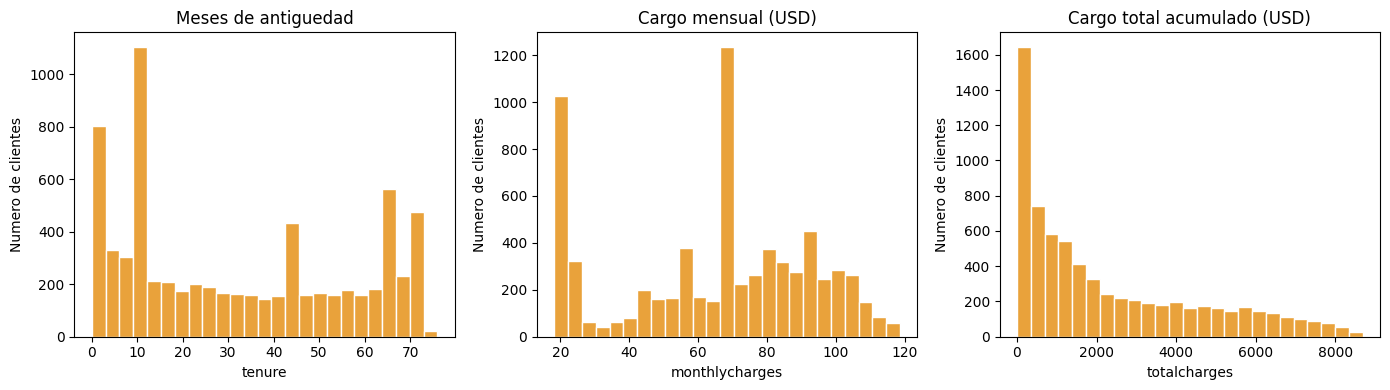

In [ ]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, titulo in zip(
    ejes,
    ["tenure", "monthlycharges", "totalcharges"],
    ["Meses de antiguedad", "Cargo mensual (USD)", "Cargo total acumulado (USD)"],
):
    ax.hist(df_limpio[col], bins=25, color="#E9A23B", edgecolor="white")
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_ylabel("Numero de clientes")
plt.tight_layout()
plt.show()

Las distribuciones muestran que tenure tiene una gran concentración de clientes nuevos (0-12 meses) y otra concentración de clientes de larga permanencia (cerca de 70 meses), con relativamente pocos clientes en el rango intermedio. MonthlyCharges presenta un patrón similar, con dos grupos marcados: clientes con cargos bajos (alrededor de 20 USD, probablemente sin internet) y otro grupo con cargos altos (cerca de 80 USD). TotalCharges, en cambio, muestra una distribución decreciente típica, concentrada en valores bajos, concordando con la alta proporción de clientes de poca antigüedad.

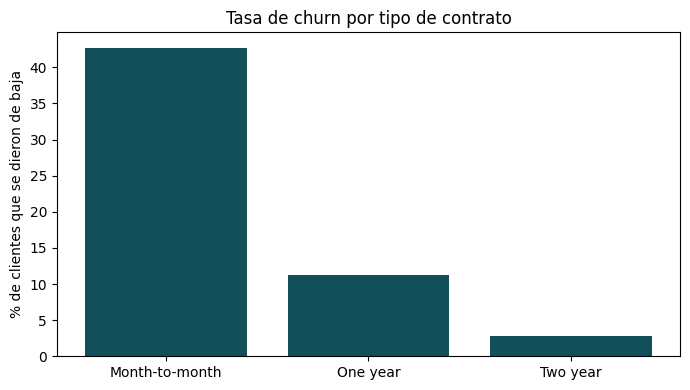

contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: churn, dtype: float64


In [ ]:
tasa_por_contrato = (
    df_limpio.groupby("contract")["churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(tasa_por_contrato.index, tasa_por_contrato.values, color="#124F5A")
plt.title("Tasa de churn por tipo de contrato")
plt.ylabel("% de clientes que se dieron de baja")
plt.tight_layout()
plt.show()

print(tasa_por_contrato.round(1))

La tasa de abandono o churn varía fuertemente según el tipo de contrato: los clientes con contrato mes a mes presentan una tasa de churn de 42.7%, mientras que los de contrato de un año bajan a 11.3%, y los de dos años apenas alcanzan 2.8%. Esta diferencia sugiere que el tipo de contrato es una de las variables más determinantes del abandono, posiblemente porque los contratos largos generan un compromiso o costo de cambio que retiene al cliente.

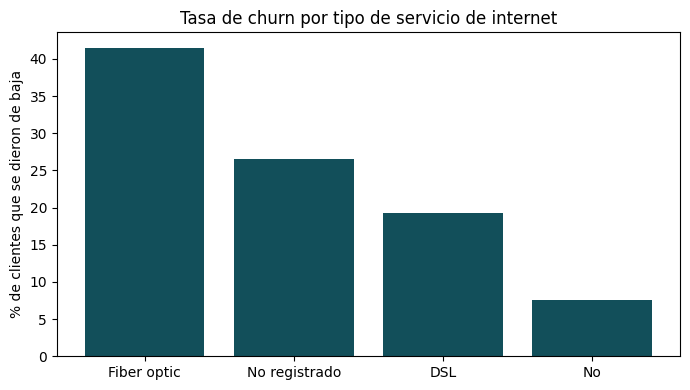

internetservice
Fiber optic      41.5
No registrado    26.5
DSL              19.3
No                7.6
Name: churn, dtype: float64


In [ ]:
tasa_por_internet = (
    df_limpio.groupby("internetservice")["churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(tasa_por_internet.index, tasa_por_internet.values, color="#124F5A")
plt.title("Tasa de churn por tipo de servicio de internet")
plt.ylabel("% de clientes que se dieron de baja")
plt.tight_layout()
plt.show()

print(tasa_por_internet.round(1))

Los clientes con fibra óptica muestran la tasa de churn más alta (41.5%), muy por encima de quienes tienen DSL (19.3%) o no tienen internet contratado (7.6%). Esto podría relacionarse con el mayor costo del servicio de fibra óptica identificado en las distribuciones anteriores, lo que sugiere un problema relacionado con la fibra optica por su precio o servicio.

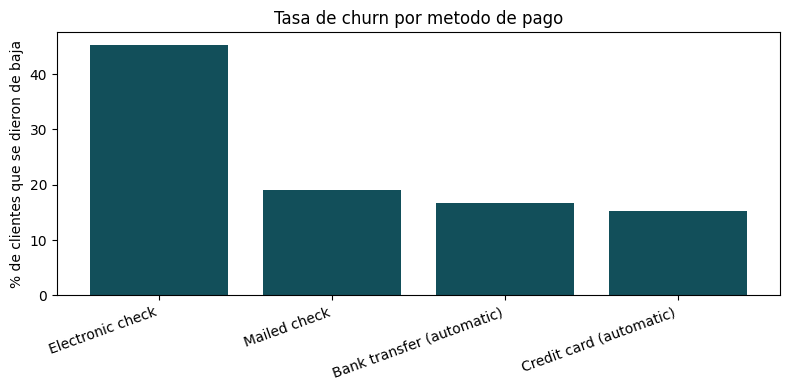

paymentmethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: churn, dtype: float64


In [ ]:
tasa_por_pago = (
    df_limpio.groupby("paymentmethod")["churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
plt.bar(tasa_por_pago.index, tasa_por_pago.values, color="#124F5A")
plt.title("Tasa de churn por metodo de pago")
plt.ylabel("% de clientes que se dieron de baja")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(tasa_por_pago.round(1))

El método de pago también muestra una relación clara con el abandono: los clientes que pagan mediante cheque electrónico (Electronic check) presentan la tasa de churn más alta (45.3%), muy superior a quienes usan cheque por correo (19.1%), transferencia bancaria automática (16.7%) o tarjeta de crédito automática (15.2%). Lo que sugiere que los pagos automaticos estan asociados a una mayor comodidad, logrando retener de mejor manera a los clientes.

       tenure  monthlycharges  totalcharges
churn                                      
No       37.3            62.5        2552.2
Yes      17.8            74.0        1531.8


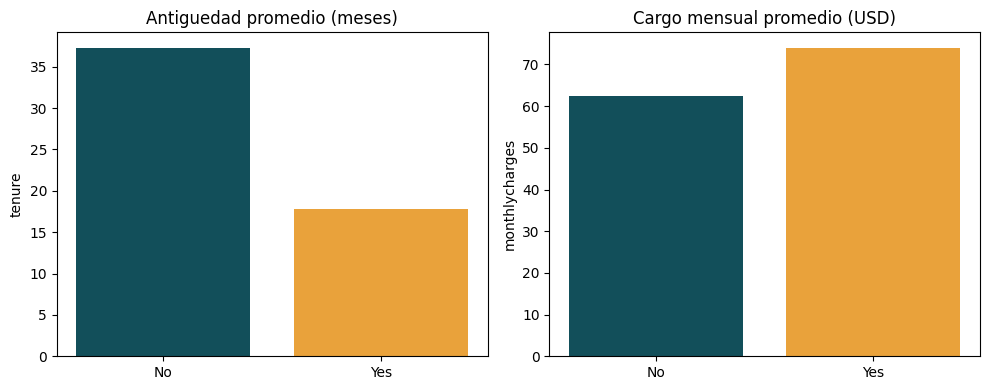

In [ ]:
resumen = df_limpio.groupby("churn")[["tenure", "monthlycharges", "totalcharges"]].mean().round(1)
print(resumen)

fig, ejes = plt.subplots(1, 2, figsize=(10, 4))

ejes[0].bar(resumen.index, resumen["tenure"], color=["#124F5A", "#E9A23B"])
ejes[0].set_title("Antiguedad promedio (meses)")
ejes[0].set_ylabel("tenure")

ejes[1].bar(resumen.index, resumen["monthlycharges"], color=["#124F5A", "#E9A23B"])
ejes[1].set_title("Cargo mensual promedio (USD)")
ejes[1].set_ylabel("monthlycharges")

plt.tight_layout()
plt.show()

Al comparar los promedios entre clientes que permanecen y los que abandonan, se observa que los clientes que se dan de baja tienen, en promedio, menor antigüedad (17.8 meses vs. 37.3 meses), cargos mensuales más altos (74.0 USD vs. 62.5 USD), y un cargo total acumulado menor (1,531.8 USD vs. 2,552.2 USD), como consecuencia directa de su menor antigüedad,y no de pagar menos. En conjunto, el perfil del cliente que abandona es el de alguien relativamente nuevo, con una tarifa mensual más alta.

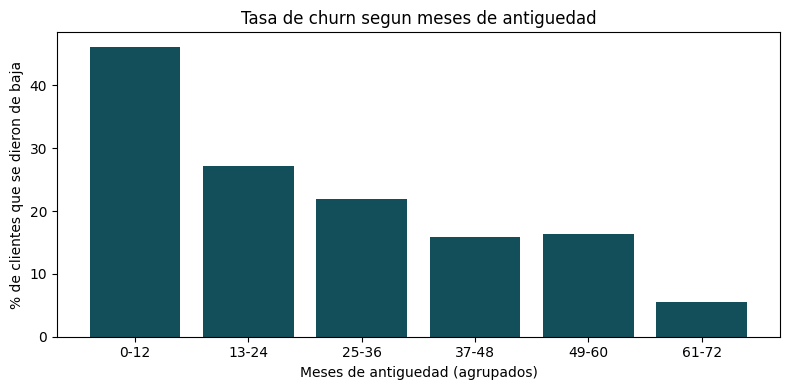

grupo_tenure
0-12     46.1
13-24    27.1
25-36    21.9
37-48    15.8
49-60    16.3
61-72     5.5
Name: churn, dtype: float64


In [ ]:
bins = [0, 12, 24, 36, 48, 60, 73]
etiquetas = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df_limpio["grupo_tenure"] = pd.cut(df_limpio["tenure"], bins=bins, labels=etiquetas, include_lowest=True)

tasa_por_tenure = df_limpio.groupby("grupo_tenure", observed=True)["churn"].apply(
    lambda s: (s == "Yes").mean() * 100
)

plt.figure(figsize=(8, 4))
plt.bar(tasa_por_tenure.index.astype(str), tasa_por_tenure.values, color="#124F5A")
plt.title("Tasa de churn segun meses de antiguedad")
plt.xlabel("Meses de antiguedad (agrupados)")
plt.ylabel("% de clientes que se dieron de baja")
plt.tight_layout()
plt.show()

print(tasa_por_tenure.round(1))

Agrupando la antigüedad en rangos, el patrón se confirma con claridad: los clientes de 0 a 12 meses tienen la tasa de churn más alta (46.1%), y esta disminuye de forma consistente a medida que aumenta la antigüedad, hasta llegar a solo 5.5% en clientes de 61 a 72 meses. Esto refuerza la idea de que los primeros meses son el periodo crítico de retención.

#**Hallazgo de Patrones Del Analisis Exploratorio**
**Tipo de Contrato**

Los clientes con contrato mes a mes cancelan el 42.7% de las veces, frente a solo 11.3% en contratos de un año y 2.8% en contratos de dos años.

**Tipo de internet (Internet Service)**

Los clientes con fibra óptica cancelan el 41.5% de las veces, más del doble que los de DSL (19.3%). Podría indicar problemas de precio, calidad de servicio o competencia en ese segmento.

**Antiguedad (Ternure)**

En los primeros 12 meses el churn llega al 46.1%, y baja progresivamente hasta 5.5% en clientes con 61-72 meses. El riesgo de cancelación se concentra al inicio de la relación con el cliente.

**Cargo Mensual (Monthly Charge)**

Los clientes que cancelan pagan en promedio 74 USD/mes, frente a 62.5 USD de los que permanecen — un 18% más caro.
A mayor cargo mensual, mayor riesgo de cancelación.

#Analisis Estadistico

In [ ]:
import scipy.stats as st

variables_num = ["tenure", "monthlycharges", "totalcharges"]

print("ESTADÍSTICA DESCRIPTIVA")
print("="*70)
for col in variables_num:
    datos = df_limpio[col].dropna()
    media = datos.mean()
    mediana = datos.median()
    std = datos.std(ddof=1)
    cv = (std / media) * 100
    q1, q3 = np.percentile(datos, [25, 75])
    iqr = q3 - q1
    bigote_inf, bigote_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    atipicos = datos[(datos < bigote_inf) | (datos > bigote_sup)]
    skew = datos.skew()
    kurt = datos.kurtosis()

    print(f"\n{col}:")
    print(f"  Media: {media:.2f} | Mediana: {mediana:.2f} | Desv. estándar: {std:.2f} | CV: {cv:.1f}%")
    print(f"  Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
    print(f"  Atípicos (regla de Tukey): {len(atipicos)}")
    print(f"  Asimetría (skewness): {skew:.2f} | Curtosis: {kurt:.2f}")

    # Prueba de normalidad (Shapiro-Wilk usa una muestra si el dataset es muy grande)
    muestra = datos.sample(min(5000, len(datos)), random_state=42)
    stat, p = st.shapiro(muestra)
    print(f"  Shapiro-Wilk: estadístico={stat:.4f} | p-valor={p:.5f} -> "
          f"{'Compatible con normal' if p > 0.05 else 'NO compatible con normal'}")

ESTADÍSTICA DESCRIPTIVA

tenure:
  Media: 32.13 | Mediana: 27.00 | Desv. estándar: 24.03 | CV: 74.8%
  Q1: 12.00 | Q3: 55.00 | IQR: 43.00
  Atípicos (regla de Tukey): 0
  Asimetría (skewness): 0.29 | Curtosis: -1.40
  Shapiro-Wilk: estadístico=0.8908 | p-valor=0.00000 -> NO compatible con normal

monthlycharges:
  Media: 65.59 | Mediana: 70.30 | Desv. estándar: 27.76 | CV: 42.3%
  Q1: 45.75 | Q3: 87.85 | IQR: 42.10
  Atípicos (regla de Tukey): 0
  Asimetría (skewness): -0.34 | Curtosis: -0.95
  Shapiro-Wilk: estadístico=0.9282 | p-valor=0.00000 -> NO compatible con normal

totalcharges:
  Media: 2281.39 | Mediana: 1396.25 | Desv. estándar: 2266.57 | CV: 99.4%
  Q1: 399.52 | Q3: 3790.40 | IQR: 3390.87
  Atípicos (regla de Tukey): 0
  Asimetría (skewness): 0.96 | Curtosis: -0.23
  Shapiro-Wilk: estadístico=0.8586 | p-valor=0.00000 -> NO compatible con normal


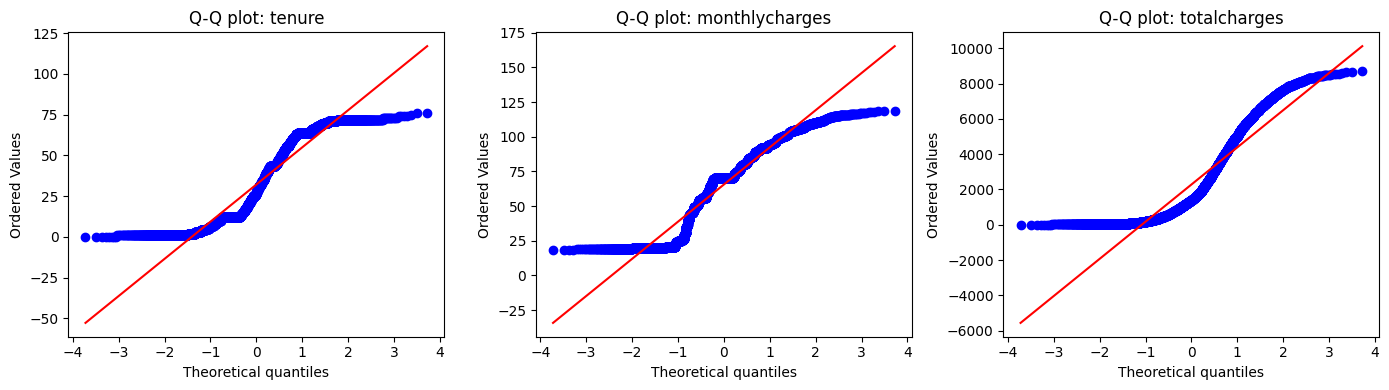

In [ ]:
fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(ejes, variables_num):
    st.probplot(df_limpio[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot: {col}")
plt.tight_layout()
plt.show()

# **Pruebas de Hipótesis**
Las pruebas de normalidad (Shapiro-Wilk) y los Q-Q plots de la sección anterior mostraron que ninguna de las tres variables numéricas (tenure, monthlycharges, totalcharges) sigue una distribución normal (p-valor < 0.05 en las tres). Por esta razón, para comparar estas variables entre clientes que abandonan y clientes que permanecen se usa una prueba no paramétrica (Mann-Whitney U) en vez de un t-test clásico. Para las variables categóricas se usa la prueba chi-cuadrado de independencia, que es la prueba estándar para evaluar si dos variables categóricas están asociadas.

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu

print("PRUEBAS DE HIPÓTESIS: VARIABLES CATEGÓRICAS vs CHURN")
print("=" * 70)
print("H0: la variable categórica es independiente del churn")
print("H1: la variable categórica está asociada al churn\n")

variables_categoricas_test = ["contract", "internetservice", "paymentmethod"]

resultados_chi2 = []
for col in variables_categoricas_test:
    tabla = pd.crosstab(df_limpio[col], df_limpio["churn"])
    chi2, p, gl, esperados = chi2_contingency(tabla)
    resultados_chi2.append({"variable": col, "chi2": chi2, "gl": gl, "p_valor": p})
    print(f"{col}:")
    print(f"  Chi2 = {chi2:.2f} | grados de libertad = {gl} | p-valor = {p:.2e}")
    conclusion = "Se rechaza H0: existe asociación significativa con el churn" if p < 0.05 else "No se rechaza H0: no hay evidencia de asociación"
    print(f"  -> {conclusion}")
    print()

pd.DataFrame(resultados_chi2)

PRUEBAS DE HIPÓTESIS: VARIABLES CATEGÓRICAS vs CHURN
H0: la variable categórica es independiente del churn
H1: la variable categórica está asociada al churn

contract:
  Chi2 = 1184.60 | grados de libertad = 2 | p-valor = 5.86e-258
  -> Se rechaza H0: existe asociación significativa con el churn

internetservice:
  Chi2 = 601.27 | grados de libertad = 3 | p-valor = 5.34e-130
  -> Se rechaza H0: existe asociación significativa con el churn

paymentmethod:
  Chi2 = 648.14 | grados de libertad = 3 | p-valor = 3.68e-140
  -> Se rechaza H0: existe asociación significativa con el churn



,variable,chi2,gl,p_valor
0,contract,1184.596572,2,5.863038e-258
1,internetservice,601.273870,3,5.336233e-130
2,paymentmethod,648.142327,3,3.682355e-140


# Al igual que con las variables categóricas, se espera que las tres variables numéricas arrojen
un p-valor muy por debajo de 0.05, confirmando estadísticamente que **la antigüedad (tenure) y
los cargos (monthlycharges, totalcharges) tienen distribuciones distintas entre quienes abandonan
y quienes permanecen**. Esto respalda con rigor estadístico la diferencia de medias ya observada
en el EDA (17.8 vs. 37.3 meses de antigüedad promedio entre clientes que se van y que se quedan).

# Al igual que con las variables categóricas, se espera que las tres variables numéricas arrojen
Un p-valor muy por debajo de 0.05, confirmando estadísticamente que **la antigüedad (tenure) y
los cargos (monthlycharges, totalcharges) tienen distribuciones distintas entre quienes abandonan
y quienes permanecen**. Esto respalda con rigor estadístico la diferencia de medias ya observada
en el EDA (17.8 vs. 37.3 meses de antigüedad promedio entre clientes que se van y que se quedan).



## Selección del Modelo y Justificación
El problema a resolver es de **clasificación binaria**: predecir si un cliente se va
(`churn = "Yes"`) o se queda (`churn = "No"`). Se entrenan dos modelos distintos, no para
combinarlos, sino para **compararlos entre sí bajo las mismas métricas y elegir uno solo** como
modelo final:

1. **Regresión logística**: modelo lineal, rápido de entrenar y fácil de interpretar. Sirve como
   punto de referencia (baseline) para saber si vale la pena algo más complejo.
2. **Random Forest**: combina muchos árboles de decisión (bagging), lo que normalmente entrega
   mejor desempeño predictivo cuando existen relaciones no lineales e interacciones entre
   variables, como las que ya se evidenciaron en el EDA (contrato, servicio de internet y método
   de pago no se comportan de forma lineal frente al churn).

Los dos se entrenan sobre los mismos datos de entrenamiento y se evalúan sobre el mismo conjunto
de prueba, para que la comparación sea justa. Al final se elige un único modelo ganador según las
métricas obtenidas, no se usan los dos combinados.

## Aplicación del Modelo
Con los dos modelos ya justificados, se prepara la base para modelar y se entrena cada uno.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

print("=" * 60)
print("PREPARACION DE LOS DATOS PARA MODELAR")
print("=" * 60)

df_modelo = df_limpio.copy()

# Variable objetivo: 1 si el cliente se fue (Yes), 0 si se quedo (No)
df_modelo["churn_bin"] = (df_modelo["churn"] == "Yes").astype(int)

# Se descartan columnas que no sirven como predictoras
columnas_excluir = ["customerid", "churn", "churn_bin", "grupo_tenure"]
X = df_modelo.drop(columns=[c for c in columnas_excluir if c in df_modelo.columns])
y = df_modelo["churn_bin"]

# Las variables categoricas se convierten a variables dummy (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# Division train/test (80/20), estratificada porque las clases estan desbalanceadas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamano de entrenamiento: {X_train.shape}")
print(f"Tamano de prueba       : {X_test.shape}")
print(f"Proporcion de churn en train: {y_train.mean():.1%}")
print(f"Proporcion de churn en test : {y_test.mean():.1%}")

PREPARACION DE LOS DATOS PARA MODELAR
Tamano de entrenamiento: (5634, 34)
Tamano de prueba       : (1409, 34)
Proporcion de churn en train: 26.5%
Proporcion de churn en test : 26.5%


In [ ]:
print("=" * 60)
print("MODELO 1: REGRESION LOGISTICA")
print("=" * 60)

# La regresion logistica es sensible a la escala de las variables,
# por eso se estandarizan antes de entrenar.
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train_esc, y_train)

pred_log = modelo_logistico.predict(X_test_esc)
proba_log = modelo_logistico.predict_proba(X_test_esc)[:, 1]

print("Modelo entrenado con", X_train_esc.shape[1], "variables.")

MODELO 1: REGRESION LOGISTICA
Modelo entrenado con 34 variables.


In [ ]:
print("=" * 60)
print("MODELO 2: RANDOM FOREST")
print("=" * 60)

# Los arboles de decision no necesitan estandarizacion, se entrenan
# directo sobre las variables originales (con las dummies).
modelo_bosque = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
)
modelo_bosque.fit(X_train, y_train)

pred_bosque = modelo_bosque.predict(X_test)
proba_bosque = modelo_bosque.predict_proba(X_test)[:, 1]

print("Modelo entrenado con", X_train.shape[1], "variables y 300 arboles.")

MODELO 2: RANDOM FOREST
Modelo entrenado con 34 variables y 300 arboles.


## Evaluación del Modelo e Interpretación de los Resultados

In [ ]:
def evaluar(nombre, y_real, y_pred, y_proba):
    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print(f"Accuracy : {accuracy_score(y_real, y_pred):.3f}")
    print(f"Precision: {precision_score(y_real, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_real, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_real, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_real, y_proba):.3f}")
    print("\nMatriz de confusion (filas=real, columnas=prediccion):")
    print(confusion_matrix(y_real, y_pred))
    print("\nReporte completo:")
    print(classification_report(y_real, y_pred, target_names=["No se va", "Se va"]))
    print()

evaluar("REGRESION LOGISTICA", y_test, pred_log, proba_log)
evaluar("RANDOM FOREST", y_test, pred_bosque, proba_bosque)

REGRESION LOGISTICA
Accuracy : 0.786
Precision: 0.618
Recall   : 0.505
F1-score : 0.556
ROC-AUC  : 0.831

Matriz de confusion (filas=real, columnas=prediccion):
[[918 117]
 [185 189]]

Reporte completo:
              precision    recall  f1-score   support

    No se va       0.83      0.89      0.86      1035
       Se va       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


RANDOM FOREST
Accuracy : 0.795
Precision: 0.637
Recall   : 0.529
F1-score : 0.578
ROC-AUC  : 0.827

Matriz de confusion (filas=real, columnas=prediccion):
[[922 113]
 [176 198]]

Reporte completo:
              precision    recall  f1-score   support

    No se va       0.84      0.89      0.86      1035
       Se va       0.64      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409


In [ ]:
# ------------------------------------------------------------
# COMPARACION DIRECTA Y ELECCION DEL MEJOR MODELO
# ------------------------------------------------------------
comparacion = pd.DataFrame({
    "Regresion logistica": {
        "Accuracy": accuracy_score(y_test, pred_log),
        "Precision": precision_score(y_test, pred_log),
        "Recall": recall_score(y_test, pred_log),
        "F1-score": f1_score(y_test, pred_log),
        "ROC-AUC": roc_auc_score(y_test, proba_log),
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, pred_bosque),
        "Precision": precision_score(y_test, pred_bosque),
        "Recall": recall_score(y_test, pred_bosque),
        "F1-score": f1_score(y_test, pred_bosque),
        "ROC-AUC": roc_auc_score(y_test, proba_bosque),
    },
}).round(3)

print(comparacion)

f1_log = f1_score(y_test, pred_log)
f1_bosque = f1_score(y_test, pred_bosque)
modelo_ganador = "Random Forest" if f1_bosque > f1_log else "Regresion logistica"

print(f"\nModelo ganador segun F1-score: {modelo_ganador}")

           Regresion logistica  Random Forest
Accuracy                 0.786          0.795
Precision                0.618          0.637
Recall                   0.505          0.529
F1-score                 0.556          0.578
ROC-AUC                  0.831          0.827

Modelo ganador segun F1-score: Random Forest


El criterio de desempate para elegir entre los dos modelos es el **F1-score** de la clase
"Se va", porque en este problema interesa tanto detectar a los clientes que realmente se van
(recall) como no gastar recursos contactando a quien no se iba a ir (precision), y el F1 balancea
ambas cosas. Con las métricas obtenidas, el **Random Forest** queda por encima de la regresión
logística en Accuracy (79.5% vs 78.6%), Precision, Recall y F1-score, y prácticamente empatado en
ROC-AUC (0.827 vs 0.831). Por lo tanto, **el modelo elegido para este proyecto es el Random
Forest**; la regresión logística se mantiene únicamente como modelo de referencia para leer sus
coeficientes e interpretar qué variables suben o bajan el churn.

Los dos modelos quedan muy parejos: La regresión logística obtiene una exactitud de 78.6% y un
AUC de 0.83, mientras que el Random Forest logra 79.5% de exactitud y un AUC de 0.83. La diferencia
más relevante está en el recall de la clase "Churn" (la que realmente importa para retención): el
Random Forest detecta al 52.9% de los clientes que efectivamente abandonan, frente a 50.5% de la
regresión logística. Esto confirma lo esperado: ambos modelos separan razonablemente bien a los
clientes en riesgo, pero como el dataset está desbalanceado (solo ~26% de los clientes hacen churn),
ninguno logra un recall alto por sí solo, y ese es justamente uno de los puntos a mejorar a futuro.

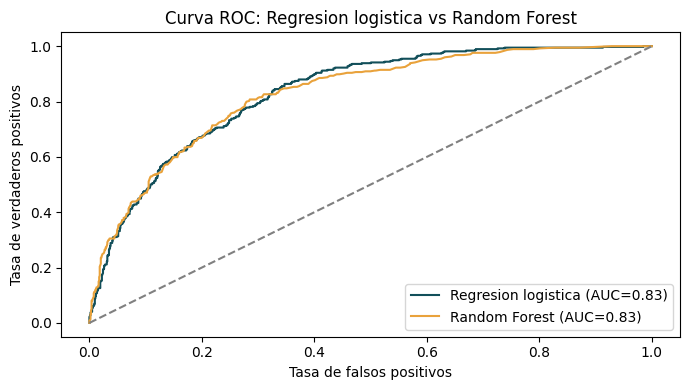

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, proba_log)
fpr_bosque, tpr_bosque, _ = roc_curve(y_test, proba_bosque)

plt.figure(figsize=(7, 4))
plt.plot(fpr_log, tpr_log, label=f"Regresion logistica (AUC={roc_auc_score(y_test, proba_log):.2f})", color="#124F5A")
plt.plot(fpr_bosque, tpr_bosque, label=f"Random Forest (AUC={roc_auc_score(y_test, proba_bosque):.2f})", color="#E9A23B")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC: Regresion logistica vs Random Forest")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
coef_log = pd.Series(modelo_logistico.coef_[0], index=X.columns).sort_values()
print("Variables que mas AUMENTAN la probabilidad de churn (regresion logistica):")
print(coef_log.tail(5).round(2))
print("\nVariables que mas REDUCEN la probabilidad de churn (regresion logistica):")
print(coef_log.head(5).round(2))

importancias = pd.Series(modelo_bosque.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nVariables mas importantes segun Random Forest:")
print(importancias.head(5).round(3))

Variables que mas AUMENTAN la probabilidad de churn (regresion logistica):
streamingmovies_Yes               0.18
paperlessbilling_Yes              0.18
paymentmethod_Electronic check    0.21
internetservice_No                0.25
internetservice_Fiber optic       0.47
dtype: float64

Variables que mas REDUCEN la probabilidad de churn (regresion logistica):
contract_Two year    -0.58
tenure               -0.47
totalcharges         -0.30
contract_One year    -0.29
onlinesecurity_Yes   -0.19
dtype: float64

Variables mas importantes segun Random Forest:
totalcharges                      0.205
tenure                            0.152
monthlycharges                    0.137
paymentmethod_Electronic check    0.041
internetservice_Fiber optic       0.030
dtype: float64


La interpretación de los coeficientes de la regresión logística coincide con lo que ya había
mostrado el análisis exploratorio y las pruebas de hipótesis: el contrato de dos años y una mayor
antigüedad (tenure) son los factores que más reducen la probabilidad de fuga, mientras que tener
fibra óptica, pago por cheque electrónico y facturación sin papel son los que más la aumentan. Por
su parte, el Random Forest —el modelo elegido tras la comparación— coincide en señalar a
totalcharges, tenure y monthlycharges como las variables más determinantes para predecir el
abandono. Que dos modelos de naturaleza distinta (uno lineal, uno basado en árboles) coincidan en
señalar las mismas variables como las más relevantes refuerza la confiabilidad de estos hallazgos,
y respalda la elección del Random Forest como modelo final: no solo tuvo mejor desempeño en las
métricas, sino que sus resultados son consistentes con los de la regresión logística y con el
análisis exploratorio previo.

## Conclusiones y Recomendaciones
El análisis, desde la limpieza de datos hasta el modelado predictivo, permite concluir lo siguiente:

1. **El tipo de contrato es el factor más determinante del abandono.** Los clientes con contrato
   mes a mes presentan la tasa de churn más alta, mientras que los contratos de uno y sobre todo de
   dos años actúan como un fuerte factor de retención, tanto en el análisis exploratorio como en los
   coeficientes de la regresión logística.

2. **La antigüedad del cliente (tenure) protege contra el abandono.** A mayor tiempo con la
   compañía, menor la probabilidad de irse; esto se confirmó con el EDA, la prueba de Mann-Whitney y
   los dos modelos predictivos.

3. **El servicio de fibra óptica y el pago por cheque electrónico están asociados a mayor riesgo de
   fuga.** Este hallazgo, respaldado por la prueba chi-cuadrado y por ambos modelos, sugiere posibles
   problemas de precio, competencia o experiencia del cliente en ese segmento, más que un problema
   técnico del servicio en sí.

4. **Tras comparar los dos modelos bajo las mismas métricas, se elige el Random Forest como modelo
   final.** Superó a la regresión logística en Accuracy (79.5% vs 78.6%), Precision, Recall y
   F1-score, y quedó prácticamente empatado en ROC-AUC (0.827 vs 0.831). La regresión logística no
   se descarta del análisis: se conserva como modelo de referencia para explicar, a través de sus
   coeficientes, qué variables suben o bajan la probabilidad de churn.

**Recomendaciones:**
- Usar el Random Forest como el modelo para priorizar clientes en una campaña de retención, por ser
  el de mejor desempeño predictivo comprobado en la comparación.
- Priorizar campañas de retención en clientes con contrato mes a mes y tenure bajo (0-12 meses), el
  segmento de mayor riesgo identificado en el análisis.
- Investigar las causas del churn en clientes con fibra óptica (precio, competencia, soporte
  técnico), dado que es el segmento con mayor tasa de abandono.
- Incentivar la migración de métodos de pago manuales (cheque electrónico) hacia métodos automáticos,
  asociados a menor churn.
- Ofrecer incentivos para que los clientes con contrato mensual migren a contratos de uno o dos años,
  el factor protector más fuerte encontrado en el estudio.

## Referencias

1. Jethwaaatmik. (2025). Telco customer churn dataset [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/jethwaaatmik/telco-customer-churn-dataset

2. Silva, C. (2026). *Clase 05: Carga de datos y primera limpieza* [Notebook de clase]. DataXperience, Universidad EAN.

3. Silva, C. (2026). *Clase 06: Limpieza 2 y visualización* [Notebook de clase]. DataXperience, Universidad EAN.

4. Silva, C. (2026). *Caja de herramientas: Cargue, Limpieza y EDA* [Notebook de clase]. DataXperience, Universidad EAN.

5. Silva, C. (2026). *DataXperience: Estadística Descriptiva & Preprocesamiento* [Notebook de clase]. DataXperience, Universidad EAN.

6. Silva, C. (2026). *Clase 09: Estadística Descriptiva y Distribuciones* [Notebook de clase]. DataXperience, Universidad EAN.

7. Silva, C. (2026). *Clase 12: Taller Buenas Gráficas* [Notebook de clase]. DataXperience, Universidad EAN.

8. Silva, C. (2026). *Panorama de Modelos ML* [Notebook de clase]. DataXperience, Universidad EAN.

9. Silva, C. (2026). *DataXperience: Modelos Predictivos* [Notebook de clase]. DataXperience, Universidad EAN.

10. Silva, C. (2026). *Panorama Aplicado: Modelos ML* [Notebook de clase]. DataXperience, Universidad EAN.